In [1]:
import glob, os, re, sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import scienceplots
from classy import Class
from scipy.interpolate import interp1d
plt.style.use(['science', 'no-latex', 'vpedre'])

LINESTYLES = plt.rcParams['axes.prop_cycle'].by_key().get('linestyle', ['-', '--', ':', '-.'])
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

tex_fonts = {
    # Use 10pt or 11pt font to match the document
    "axes.labelsize": 12,
    "font.size": 12,
    # Make the legend/ticks slightly smaller
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

thesis_width = 472.03123

def set_size(width, fraction=1, subplots=(1, 1)):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    -----a-----
    width: float
            Document textwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

fig_dims = set_size(thesis_width)

In [2]:
kk = np.array([1e-3, 1e-2, 1e-1])

base = {
    # 'H0'      : 67,
    # 'Omega_b' : 0.049,
    # 'Omega_cdm': 0.27,
    # 'A_s'     : 2.6e-9,
    # 'n_s'     : 0.96,
    # 'k_pivot' : 0.05,
    'output'  : 'tCl mPk dTk vTk',
    'k_output_values': ','.join([str(k) for k in kk]),
    'z_max_pk': 5,
    # 'evolver': 0,
}

def class_w0wa(w0, wa):
    p = dict(base)
    p.update({'Omega_Lambda': 0, 'w0_fld': w0, 'wa_fld': wa, 'cs2_fld': 1.})
    return p

def mochi_w0wa(w0, wa):
    """GR-limit scalar field with CPL expansion history."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/gr.dat',
        'parameters_smg': '1e-10',
        'expansion_model': 'w0wa',
        'expansion_smg' : f'0.67, {w0}, {wa}',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_frhs():
    """HS f(R) with CPL expansion history using background-consistent stable_params."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/hs_fr_stable_params_fr0_1em4_n_1_mathematica.dat',
        'parameters_smg': '6.061178756035e-5',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_hs_fr_n_1_fr0_1em4_mathematica.dat',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_cgal():
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/cubic_galileon_stable_params_mathematica.dat',
        'parameters_smg': '1.380051990990777',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_cubic_galileon_mathematica.dat',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p


w0_values = np.array([-1.3, -1.0])
wa_values = np.array([-0.6, 0.0])

W0, Wa = np.meshgrid(w0_values, wa_values)
models_to_run = {}

for w0, wa in zip(W0.ravel(), Wa.ravel()):
    models_to_run[f'lcdm_w0={w0}_wa={wa}']      = class_w0wa(w0, wa)
    models_to_run[f'mochi_lcdm_w0={w0}_wa={wa}'] = mochi_w0wa(w0, wa)


In [3]:
cosmo = {}
bk    = {}
pt    = {}

for name, pars in models_to_run.items():
    print(f'Computing {name}...', end=' ', flush=True)
    cosmo[name] = Class()
    cosmo[name].set(pars)
    # try:
    cosmo[name].compute()
    # except:
        # print('problem')
        # continue
    bk[name] = cosmo[name].get_background()
    pt[name] = cosmo[name].get_perturbations()['scalar']
    print('done')

Computing lcdm_w0=-1.3_wa=-0.6... done
Computing mochi_lcdm_w0=-1.3_wa=-0.6... done
Computing lcdm_w0=-1.0_wa=-0.6... done
Computing mochi_lcdm_w0=-1.0_wa=-0.6... done
Computing lcdm_w0=-1.3_wa=0.0... done
Computing mochi_lcdm_w0=-1.3_wa=0.0... done
Computing lcdm_w0=-1.0_wa=0.0... done
Computing mochi_lcdm_w0=-1.0_wa=0.0... done


In [4]:
idx = 2
list(models_to_run.keys())[idx:2+idx]

['lcdm_w0=-1.0_wa=-0.6', 'mochi_lcdm_w0=-1.0_wa=-0.6']

In [5]:
def plot_de_pert(pert_key, k_idx=0, skip='black'):
    fig, ax = plt.subplots()

    for model in models_to_run.keys():
        if skip in model:
            continue
        if 'mochi' in model:
            aa      = pt[model][k_idx]['a']
            pert    = pt[model][k_idx][f'{pert_key}_smg']#/pt[model][k_idx][f'{pert_key}_smg'][-1]
            label=model
        else:
            aa      = pt[model][k_idx]['a']
            try:
                pert    = pt[model][k_idx][f'{pert_key}_fld']#/pt[model][k_idx][f'{pert_key}_fld'][-1]
            except:
                pert = np.zeros_like(aa)
            label='lcdm'
        ax.semilogx(aa, pert, label=label)
        ax.set_title(pert_key)
    ax.legend()


def plot_de(k_list=kk, skip='None', index=0):
    fig, axes = plt.subplots(len(k_list), 3, figsize=(fig_dims[0]*1.5*0.68, fig_dims[1]*1.9*0.68), sharex=True)
    for k_idx, k in enumerate(k_list):
        for model in list(models_to_run.keys())[index:index+2]:
            ax_row = axes[k_idx]
            d = pt[model][k_idx]
            if skip in model:
                continue
            if 'mochi' not in model:
                aa = d['a']
                try:
                    delta   = d['delta_fld']
                    theta   = d['theta_fld']
                    shear   = d['shear_fld']
                except:
                    delta = np.zeros_like(aa)
                    theta = np.zeros_like(aa)
                    shear = np.zeros_like(aa)
                label = r'\texttt{CLASS} $\Lambda$CDM'
                ls=LINESTYLES[0]
            else:
                aa      = d['a']
                delta   = d['delta_smg']
                theta   = d['theta_smg']
                shear   = d['shear_smg']
                lbl = model.split('_')[1]
                if lbl == 'lcdm':
                    label = r'\texttt{mochi} $\Lambda$CDM'
                    ls=LINESTYLES[1]
                elif lbl == 'frhs':
                    label = r'\texttt{mochi} $f(R)$ HS'
                    ls=LINESTYLES[2]
                else:
                    label = r'\texttt{mochi} cGalileon'
                    ls=LINESTYLES[3]

            ax_row[0].semilogx(aa, delta, label=label, ls=ls)
            ax_row[1].semilogx(aa, theta, label=label, ls=ls)
            ax_row[2].semilogx(aa, shear, label=label, ls=ls)
            
            ax_row[0].set_ylabel(rf'$k={k}$ ' r'Mpc$^{-1}$')

    axes[0][0].set_title(r'$\delta_{\rm DE}(a)$')
    axes[0][1].set_title(r'$\theta_{\rm DE}(a)$')
    axes[0][2].set_title(r'$\sigma_{\rm DE}(a)$')
    axes[0][2].legend()
    plt.tight_layout()
    fig.suptitle(r'Evolution of Dark Energy Perturbations', y=1.01)
    fig.supxlabel('Scale factor $a$', y=-0.01)
    # fig.savefig('../imgs/de_perturbations.pdf')

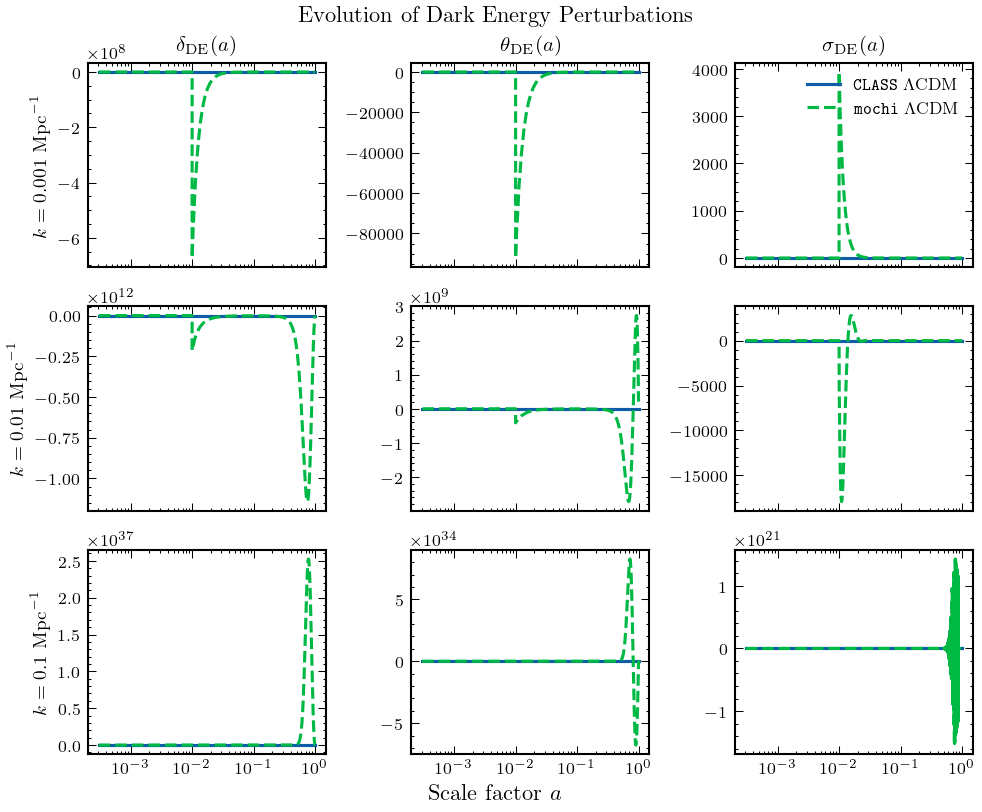

In [6]:
plot_de(index=0)

In [7]:
k_arr = np.logspace(-4, 0, 500)  # k in 1/Mpc

Pk = {}
for name in models_to_run.keys():
    Pk[name] = np.array([cosmo[name].pk_lin(k, 0.0) for k in k_arr])

KeyError: 'mochi_frhs'

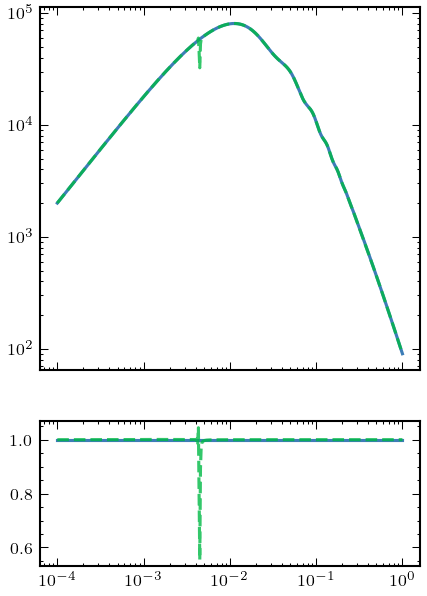

In [8]:
lcdm_ref = 'lcdm_w0=-1.0_wa=0.0'

model_labels = {
    'lcdm_w0=-1.0_wa=0.0'       : r'\texttt{CLASS} $\Lambda$CDM',
    'mochi_lcdm_w0=-1.0_wa=0.0' : r'\texttt{mochi} $\Lambda$CDM',
    'mochi_frhs'                 : r'\texttt{mochi} $f(R)$ HS',
    'mochi_cgal'                 : r'\texttt{mochi} cGalileon',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_dims[0]*.5, fig_dims[1]*1.2), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2]})

for i, (name, label) in enumerate(model_labels.items()):
    ax1.loglog(k_arr, Pk[name], alpha=0.8, ls=LINESTYLES[i], label=label)
    ax2.semilogx(k_arr, Pk[name]/Pk[lcdm_ref], alpha=0.8, ls=LINESTYLES[i])

ax1.set_ylabel(r'$P_{\rm lin}(k)$ [Mpc$^3$]')
ax2.set_ylabel(r'Residual [\%]')
fig.suptitle(r'Linear Matter Power Spectrum at $z=0$', y=0.9)
fig.supxlabel(r'$k$ [Mpc$^{-1}$]', y=0.07)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
ax1.legend()
fig.savefig('../imgs/matter_power_spectrum.pdf')